In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier

In [2]:
DATA_PATH = Path("../data/synthetic/recovery_events.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 15)


In [3]:
FEATURES = [
    "amount",
    "payment_method",
    "event_type",
    "failure_reason",
    "attempt_number",
    "customer_segment",
    "days_since_failure",
    "previous_success_rate",
    "customer_lifetime_value",
    "is_subscription",
    "invoice_age",
]

TARGET = "recovered"

X = df[FEATURES]
y = df[TARGET]

In [4]:
categorical_features = [
    "payment_method",
    "event_type",
    "failure_reason",
    "customer_segment",
]

numerical_features = [
    "amount",
    "attempt_number",
    "days_since_failure",
    "previous_success_rate",
    "customer_lifetime_value",
    "is_subscription",
    "invoice_age",
]

In [5]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (8000, 11)
Testing: (2000, 11)


In [7]:
#Logistic Regretion
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

In [9]:
#Randome Forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [10]:
#XGBoost
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [11]:
#Training the models
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model,
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    print("Done.")


Training Logistic Regression...
Done.

Training Random Forest...
Done.

Training XGBoost...
Done.


In [12]:
def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
    }

    return metrics

In [13]:
results = []

for name, model in models.items():
    results.append(
        evaluate_model(
            name,
            model,
            X_test,
            y_test,
        )
    )

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.6025,0.686973,0.613903,0.648386,0.634128,0.701853
1,Random Forest,0.5855,0.663092,0.621441,0.641591,0.607971,0.684813
2,XGBoost,0.6125,0.640888,0.798157,0.710929,0.598506,0.668590


In [15]:
#Confusion matrix
best_model_name = results_df.sort_values(
    "PR-AUC",
    ascending=False,
).iloc[0]["Model"]

print("Best model:", best_model_name)

best_model = models[best_model_name]

Best model: Logistic Regression


In [16]:
predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print(cm)

[[472 334]
 [461 733]]


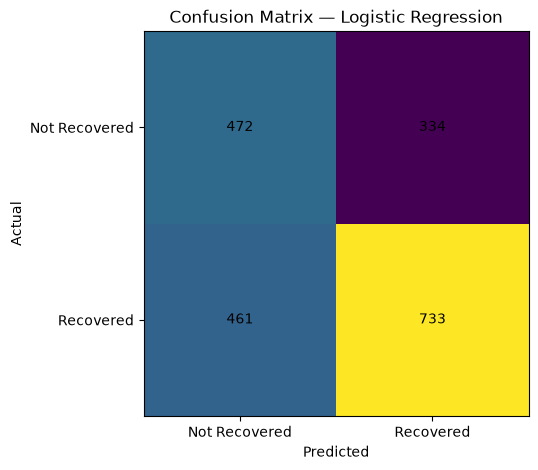

In [17]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Recovered", "Recovered"])
plt.yticks([0, 1], ["Not Recovered", "Recovered"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.show()

In [18]:
test_predictions = X_test.copy()

test_predictions["actual_recovered"] = y_test.values

test_predictions["recovery_probability"] = (
    best_model.predict_proba(X_test)[:, 1]
)

test_predictions["amount"] = df.loc[
    X_test.index,
    "amount",
].values

In [19]:
THRESHOLD = 0.70
test_predictions["recommended"] = (
    test_predictions["recovery_probability"] >= THRESHOLD
)
recommended = test_predictions[
    test_predictions["recommended"]
]

print(
    "Transactions recommended for recovery:",
    len(recommended),
)

print(
    "Potential revenue:",
    f"₹{recommended['amount'].sum():,.2f}",
)


Transactions recommended for recovery: 108
Potential revenue: ₹306,503.29


In [20]:
actually_recovered = recommended[
    recommended["actual_recovered"] == 1
]

recovered_amount = actually_recovered["amount"].sum()

print(
    f"Expected/observed recovered revenue: "
    f"₹{recovered_amount:,.2f}"
)

Expected/observed recovered revenue: ₹234,151.27


In [21]:
total_targeted = recommended["amount"].sum()

revenue_precision = (
    recovered_amount / total_targeted
    if total_targeted > 0
    else 0
)

print(
    f"Revenue precision: "
    f"{revenue_precision:.2%}"
)

Revenue precision: 76.39%


In [22]:
threshold_results = []

for threshold in np.arange(0.50, 0.96, 0.05):

    selected = test_predictions[
        test_predictions["recovery_probability"] >= threshold
    ]

    if len(selected) == 0:
        continue

    recovered = selected[
        selected["actual_recovered"] == 1
    ]

    targeted_revenue = selected["amount"].sum()
    recovered_revenue = recovered["amount"].sum()

    threshold_results.append(
        {
            "threshold": threshold,
            "transactions_targeted": len(selected),
            "targeted_revenue": targeted_revenue,
            "recovered_revenue": recovered_revenue,
            "recovery_rate": (
                len(recovered) / len(selected)
            ),
        }
    )

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,transactions_targeted,targeted_revenue,recovered_revenue,recovery_rate
0,0.50,1067,2285542.45,1579983.34,0.686973
1,0.55,767,1626420.71,1144599.03,0.702738
2,0.60,485,1059778.71,769429.42,0.717526
3,0.65,272,641470.10,482579.55,0.757353
4,0.70,108,306503.29,234151.27,0.805556
5,0.75,24,93077.40,82040.51,0.833333
6,0.80,4,49207.33,43271.34,0.500000


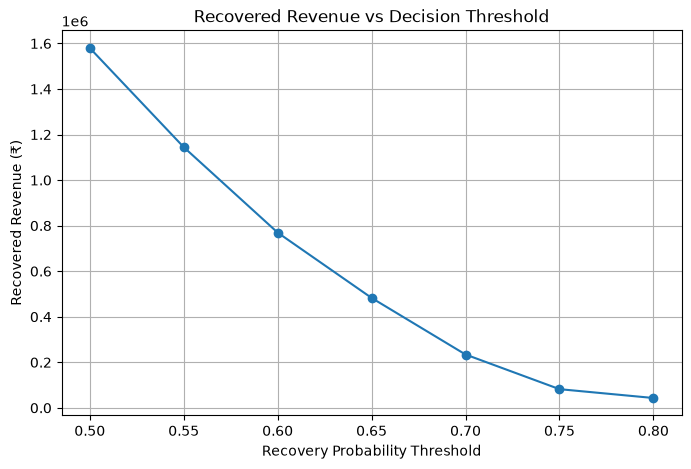

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["recovered_revenue"],
    marker="o",
)

plt.title("Recovered Revenue vs Decision Threshold")
plt.xlabel("Recovery Probability Threshold")
plt.ylabel("Recovered Revenue (₹)")
plt.grid(True)

plt.show()

In [24]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    MODEL_DIR / "recovery_model.joblib",
)

print("Model saved.")

Model saved.


In [25]:
results_df.to_csv(
    "../models/model_comparison.csv",
    index=False,
)

threshold_df.to_csv(
    "../models/threshold_analysis.csv",
    index=False,
)

print("Evaluation results saved.")

Evaluation results saved.


In [26]:
joblib.dump(
    xgb_model,
    "../models/xgboost_recovery_model.joblib",
)

print("XGBoost model saved.")

XGBoost model saved.
